# EfficientDet 실습 — 정리본

> 원본 코드와 실행 결과는 **그대로 두고**, 각 코드 셀 아래에 `💬 코멘트` 셀을 달아 흐름·의미·주의할 점을 정리했습니다.
> 마지막에 **결과 분석 및 개선 방안**과 **느낀 점**을 추가했습니다.

### 전체 흐름
| 단계 | 내용 | 결과 |
|---|---|---|
| 1. 환경 설정 | 저장소 clone, D0 사전학습 가중치 다운로드, 모델 로드 | COCO 90클래스 모델 준비 |
| 2. 이미지 추론 | 전처리 → 추론 → 후처리(박스 변환·NMS) → 시각화 | 후보 49,104개 → 박스 37개 |
| 3. 영상 추론 | 축구 영상(`soccer.mp4`) 프레임별 탐지 → mp4로 합치기 | `output_soccer.mp4` |
| 4. 데이터 준비 | Kaggle 차량 데이터, mean/std·앵커 분석, 폴더/json 변환, yml 작성 | 6클래스 데이터셋 |
| 5. 학습 | head만 10 epoch → 전체 학습(중단) | Val loss 5805 → 110 |
| 6. 평가·추론 | COCO 평가, 테스트 이미지 추론 | AP = 0.000 |

## 1. 라이브러리 설치 및 환경 설정

In [1]:
!git clone https://github.com/zylo117/Yet-Another-EfficientDet-Pytorch.git
# !pip install opencv-python matplotlib pycocotools

Cloning into 'Yet-Another-EfficientDet-Pytorch'...
remote: Enumerating objects: 765, done.
remote: Total 765 (delta 0), reused 0 (delta 0), pack-reused 765 (from 1)
Receiving objects: 100% (765/765), 8.84 MiB | 15.51 MiB/s, done.
Resolving deltas: 100% (437/437), done.


> 💬 **코멘트**
>
> EfficientDet을 PyTorch로 구현한 **zylo117/Yet-Another-EfficientDet-Pytorch** 저장소를 내려받는다.
> - 모델 구조(`backbone.py`), 전·후처리 함수(`utils/`), 학습(`train.py`)·평가(`coco_eval.py`) 스크립트가 모두 들어 있어서 이후 실습 전체가 이 저장소 기준으로 진행된다.
> - `pip install`은 Colab에 이미 설치된 라이브러리라 주석 처리해 둔 것.

In [2]:
import os

os.chdir('Yet-Another-EfficientDet-Pytorch')
print("현재 디렉토리:", os.getcwd())

현재 디렉토리: /content/Yet-Another-EfficientDet-Pytorch


> 💬 **코멘트**
>
> 작업 디렉토리를 저장소 폴더로 이동한다.
> - 이후 `from backbone import ...`, `from utils.utils import ...` 같은 import가 **이 폴더 기준 상대 경로**라서 이 이동이 꼭 필요하다.

In [3]:
!mkdir -p weights
!wget https://github.com/zylo117/Yet-Another-Efficient-Pytorch/releases/download/1.0/efficientdet-d0.pth -O weights/efficientdet-d0.pth

--2026-09-15 05:45:41--  https://github.com/zylo117/Yet-Another-Efficient-Pytorch/releases/download/1.0/efficientdet-d0.pth
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://github.com/zylo117/Yet-Another-EfficientDet-Pytorch/releases/download/1.0/efficientdet-d0.pth [following]
--2026-09-15 05:45:41--  https://github.com/zylo117/Yet-Another-EfficientDet-Pytorch/releases/download/1.0/efficientdet-d0.pth
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/253385242/9b9d2100-791d-11ea-80b2-d35899cf95fe?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-09-15T06%3A35%3A06Z&rscd=attachment%3B+filename%3Defficientdet-d0.pth&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-

> 💬 **코멘트**
>
> 사전학습(COCO) 가중치 **EfficientDet-D0**(약 15MB)를 `weights/` 폴더에 받는다.
> - URL의 저장소 이름이 실제와 조금 다르지만(`...Efficient-Pytorch`) GitHub가 301 리다이렉트로 처리해 줘서 정상 저장됐다.

In [4]:
import torch
from backbone import EfficientDetBackbone
compound_coef = 0
model = EfficientDetBackbone(compound_coef=0, num_classes=90)

> 💬 **코멘트**
>
> 모델 뼈대를 만든다.
> - `compound_coef=0` → **D0**: EfficientDet 중 가장 작은 모델(입력 512px). 숫자가 커질수록 backbone·BiFPN·입력 해상도가 함께 커지는 것이 EfficientDet의 **compound scaling**.
> - `num_classes=90` → COCO 클래스 수에 맞춰야 사전학습 가중치가 그대로 들어간다.

In [5]:
model.load_state_dict(torch.load(f'weights/efficientdet-d0.pth', map_location='cpu'))
model.requires_grad_(False)
model.eval()

EfficientDetBackbone(
  (bifpn): Sequential(
    (0): BiFPN(
      (conv6_up): SeparableConvBlock(
        (depthwise_conv): Conv2dStaticSamePadding(
          (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), groups=64, bias=False)
        )
        (pointwise_conv): Conv2dStaticSamePadding(
          (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
        )
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      )
      (conv5_up): SeparableConvBlock(
        (depthwise_conv): Conv2dStaticSamePadding(
          (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), groups=64, bias=False)
        )
        (pointwise_conv): Conv2dStaticSamePadding(
          (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
        )
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      )
      (conv4_up): SeparableConvBlock(
        (depthwise_conv): Conv2dStaticSamePadding(
      

> 💬 **코멘트**
>
> 가중치를 불러오고 **추론 모드**로 전환한다.
> - `requires_grad_(False)`: 학습하지 않으니 gradient 계산을 끔 → 메모리 절약
> - `eval()`: BatchNorm·Dropout을 추론용 동작으로 바꿈 (안 하면 결과가 매번 달라질 수 있음)

In [6]:
compound_coef = 0
force_input_size = None  # set None to use default size
# img_path = 'bus.jpg'

# replace this part with your project's anchor config
anchor_ratios = [(1.0, 1.0), (1.4, 0.7), (0.7, 1.4)]
anchor_scales = [2 ** 0, 2 ** (1.0 / 3.0), 2 ** (2.0 / 3.0)]

threshold = 0.2
iou_threshold = 0.2

use_cuda = True
use_float16 = False


> 💬 **코멘트**
>
> 추론 설정값.
> - `anchor_ratios / anchor_scales`: COCO 기본 앵커. 앵커 하나당 비율 3 × 크기 3 = **9개**.
> - `threshold=0.2`: 점수 0.2 이상인 박스만 남김
> - `iou_threshold=0.2`: NMS에서 IoU 0.2 넘게 겹치면 중복으로 보고 제거
> - 두 값 모두 낮은 편이라 박스가 많이 나오는 쪽으로 설정한 것.

In [7]:
obj_list = ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light',
            'fire hydrant', '', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep',
            'cow', 'elephant', 'bear', 'zebra', 'giraffe', '', 'backpack', 'umbrella', '', '', 'handbag', 'tie',
            'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove',
            'skateboard', 'surfboard', 'tennis racket', 'bottle', '', 'wine glass', 'cup', 'fork', 'knife', 'spoon',
            'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut',
            'cake', 'chair', 'couch', 'potted plant', 'bed', '', 'dining table', '', '', 'toilet', '', 'tv',
            'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink',
            'refrigerator', '', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier',
            'toothbrush']

> 💬 **코멘트**
>
> COCO 클래스 이름 목록.
> - 중간중간 있는 `''`(빈 문자열)은 COCO 원본에서 **비어 있는 category_id 자리**를 채운 것. 그래야 모델 출력 인덱스와 이름이 정확히 맞는다.

In [8]:
len(obj_list)

90

> 💬 **코멘트**
>
> 출력 **90** → 모델의 `num_classes=90`과 일치하는지 확인.

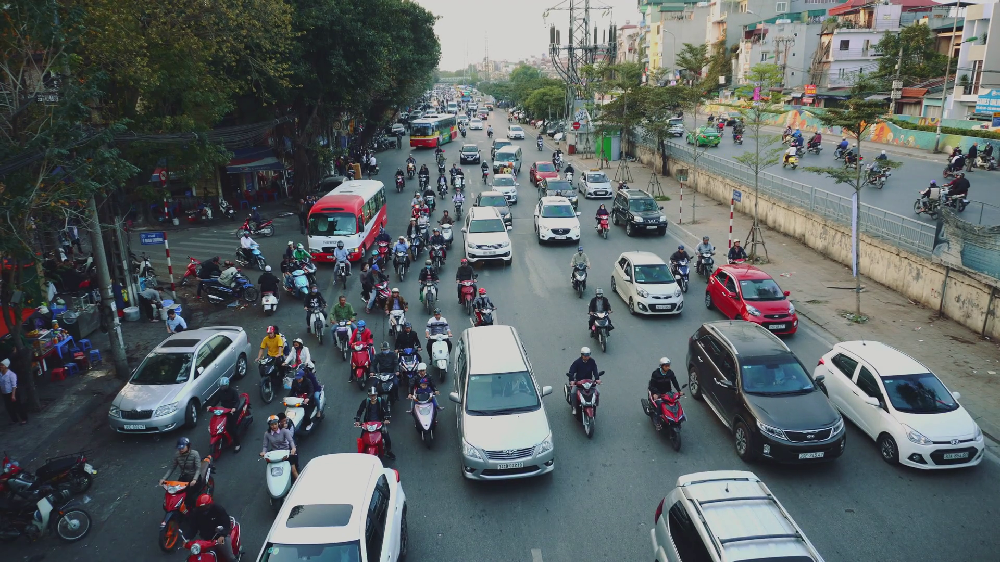

In [9]:
from PIL import Image
Image.open('test/img.png')

> 💬 **코멘트**
>
> 추론에 사용할 테스트 이미지(저장소에 포함된 `test/img.png`)를 먼저 눈으로 확인.

In [10]:
from utils.utils import preprocess, invert_affine, postprocess, STANDARD_COLORS, standard_to_bgr, get_index_label, plot_one_box

img_path = 'test/img.png'
color_list = standard_to_bgr(STANDARD_COLORS)
input_sizes = [512, 640, 768, 896, 1024, 1280, 1280, 1536, 1536]
input_size = input_sizes[compound_coef] if force_input_size is None else force_input_size
ori_imgs, framed_imgs, framed_metas = preprocess(img_path, max_size=input_size)
if use_cuda:
    x = torch.stack([torch.from_numpy(fi).cuda() for fi in framed_imgs], 0)
else:
    x = torch.stack([torch.from_numpy(fi) for fi in framed_imgs], 0)
x = x.to(torch.float32 if not use_float16 else torch.float16).permute(0, 3, 1, 2)

> 💬 **코멘트**
>
> **전처리** 단계.
> - `preprocess()`: 원본 비율을 유지하며 긴 변을 512로 줄이고, 남는 부분은 패딩해서 512×512 정사각형으로 만든 뒤 mean/std로 정규화.
> - `framed_metas`: 나중에 박스 좌표를 **원본 크기로 되돌리기 위한 정보**(리사이즈 크기, 패딩 등).
> - 마지막 `permute(0, 3, 1, 2)`: OpenCV 형식 (N, H, W, C) → PyTorch 형식 (N, C, H, W).

In [11]:
ori_imgs[0].shape, framed_imgs[0].shape

((1080, 1920, 3), (512, 512, 3))

> 💬 **코멘트**
>
> 원본 `(1080, 1920, 3)` → 모델 입력 `(512, 512, 3)`.
> 가로 1920이 512로 줄어들면서 세로는 288이 되고, 나머지는 패딩으로 채워졌다.

In [12]:
framed_metas

[(512, 288, 1920, 1080, 0, 224)]

> 💬 **코멘트**
>
> `(512, 288, 1920, 1080, 0, 224)` = (리사이즈 후 W, H, 원본 W, H, 가로 패딩, 세로 패딩).
> 288 + 224 = 512 → 세로 아래쪽에 224px 패딩이 붙었다는 뜻.

In [13]:
if use_cuda:
    model = model.cuda()
if use_float16:
    model = model.half()
with torch.no_grad():
    features, regression, classification, anchors = model(x)

> 💬 **코멘트**
>
> 모델 **순전파(forward)**. 출력 4가지:
> - `features`: BiFPN을 거친 다중 스케일 특징맵
> - `regression`: 앵커 기준 박스 위치 보정값 (dx, dy, dw, dh)
> - `classification`: 앵커별 90개 클래스 확률
> - `anchors`: 미리 깔아 둔 기준 박스들

In [14]:
features[0].shape, regression[0].shape, classification.shape, anchors.shape

(torch.Size([1, 64, 64, 64]),
 torch.Size([49104, 4]),
 torch.Size([1, 49104, 90]),
 torch.Size([1, 49104, 4]))

> 💬 **코멘트**
>
> **49104**개의 앵커가 어디서 나오는지 계산해 보면:
> (64² + 32² + 16² + 8² + 4²) × 9 = 5456 × 9 = **49104**
> → 5개 특징맵의 모든 위치마다 앵커 9개씩. 이미지 한 장에서 이 4만 9천 개 후보 중 진짜 물체를 골라내는 구조다.
> (`regression[0]`은 배치 첫 장이라 앞의 배치 차원이 빠져 있음)

In [15]:
len(features)

5

> 💬 **코멘트**
>
> 특징맵이 **5개** → P3 ~ P7 레벨.

In [16]:
features[0].shape, features[1].shape, features[2].shape, features[3].shape, features[4].shape

(torch.Size([1, 64, 64, 64]),
 torch.Size([1, 64, 32, 32]),
 torch.Size([1, 64, 16, 16]),
 torch.Size([1, 64, 8, 8]),
 torch.Size([1, 64, 4, 4]))

> 💬 **코멘트**
>
> 채널은 모두 64(D0의 BiFPN 폭), 해상도는 64 → 32 → 16 → 8 → 4로 절반씩 줄어든다.
> - 큰 특징맵(64×64): **작은 물체** 담당
> - 작은 특징맵(4×4): **큰 물체** 담당
> - BiFPN은 이 레벨들을 위아래로 여러 번 섞어서(양방향 + 가중 합) 크기가 다른 물체를 모두 잘 잡도록 해 준다.

In [17]:
from utils.utils import postprocess
from efficientdet.utils import BBoxTransform, ClipBoxes

with torch.no_grad():
    features, regression, classification, anchors = model(x)
    regressBoxes = BBoxTransform() # 모델이 예측한 regression 값을 실제 bounding box 좌표로 변환
    clipBoxes = ClipBoxes()        # 모델이 예측한 object의 box가 이미지 범위를 벗어나지 않도록 조정
    out = postprocess(x,
                      anchors, regression, classification,
                      regressBoxes, clipBoxes,
                      threshold, iou_threshold)


> 💬 **코멘트**
>
> **후처리** 단계.
> - `BBoxTransform`: 앵커 + regression 보정값 → 실제 박스 좌표 (x1, y1, x2, y2)
> - `ClipBoxes`: 이미지 밖으로 나간 박스를 경계에 맞게 자름
> - `postprocess`: threshold로 점수 낮은 박스 제거 → NMS로 중복 박스 제거

In [18]:
out

[{'rois': array([[333.90854   , 239.91882   , 424.3854    , 287.47577   ],
         [314.5766    , 129.69444   , 351.32953   , 163.35027   ],
         [350.1861    , 165.45123   , 433.3695    , 241.53812   ],
         [130.68173   , 232.13904   , 207.67441   , 287.58868   ],
         [362.0021    , 135.14642   , 408.66135   , 169.6908    ],
         [ 56.52711   , 167.49118   , 129.53185   , 224.72946   ],
         [414.87576   , 173.1823    , 506.79477   , 242.5576    ],
         [  0.8863888 , 233.43379   ,  48.700577  , 277.26804   ],
         [ 80.504974  , 246.79994   , 122.74979   , 286.69684   ],
         [232.99295   , 165.08078   , 285.2722    , 247.46469   ],
         [155.38026   ,  93.80188   , 196.91176   , 136.37054   ],
         [330.41702   , 184.25446   , 351.00174   , 229.17694   ],
         [290.06638   , 180.93594   , 309.02835   , 222.59875   ],
         [236.92749   , 112.801186  , 263.35803   , 136.6008    ],
         [316.67487   ,  98.806     , 343.58368   , 12

> 💬 **코멘트**
>
> 결과는 이미지별 dict: `rois`(박스 좌표), `class_ids`(클래스 번호), `scores`(신뢰도).

In [19]:
out[0]['rois'].shape, out[0]['class_ids'].shape, out[0]['scores'].shape

((37, 4), (37,), (37,))

> 💬 **코멘트**
>
> 49104개 후보 → 최종 **37개** 박스가 살아남았다.

In [20]:
import cv2
def display(preds, imgs, imshow=True, imwrite=False):
    for i in range(len(imgs)):
        if len(preds[i]['rois']) == 0:
            continue

        imgs[i] = imgs[i].copy()

        for j in range(len(preds[i]['rois'])):
            x1, y1, x2, y2 = preds[i]['rois'][j].astype(np.int32)
            obj = obj_list[preds[i]['class_ids'][j]]
            score = float(preds[i]['scores'][j])
            plot_one_box(imgs[i], [x1, y1, x2, y2], label=obj,score=score,color=color_list[get_index_label(obj, obj_list)])


        if imshow:
            cv2.imshow('img', imgs[i])
            cv2.waitKey(0)

        if imwrite:
            cv2.imwrite(f'test/img_inferred_d{compound_coef}_this_repo_{i}.jpg', imgs[i])

    return f'test/img_inferred_d{compound_coef}_this_repo_'



> 💬 **코멘트**
>
> 박스를 이미지 위에 그리는 함수.
> - `cv2.imshow`는 Colab에서 동작하지 않아서 `imshow=False, imwrite=True`로 **파일 저장**하는 방식을 사용.
> - 함수 안에서 `np`를 쓰는데 `numpy` import는 다음 셀에서 한다(호출 시점엔 import되어 있어서 문제없음).

In [21]:
import numpy as np
out = invert_affine(framed_metas, out)
img_path = display(out, ori_imgs, imshow=False, imwrite=True)

> 💬 **코멘트**
>
> `invert_affine()`: 512×512 기준 박스 좌표를 `framed_metas`를 이용해 **원본(1920×1080) 좌표로 복원**한 뒤 그림을 그려 저장.

In [22]:
img_path

'test/img_inferred_d0_this_repo_'

> 💬 **코멘트**
>
> 저장된 결과 파일 경로의 앞부분. 실제 파일명은 뒤에 `0.jpg`가 붙는다.

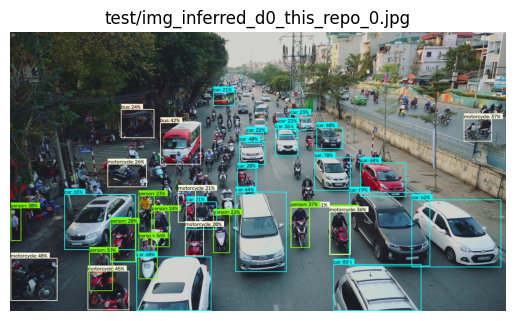

In [23]:
from PIL import Image
import matplotlib.pyplot as plt

img_path = f"{img_path}0.jpg"  # 파일 확장자에 따라 수정 가능

img = Image.open(img_path)

# 이미지 출력
plt.imshow(img)
plt.axis('off')  # 축 제거
plt.title(img_path)
plt.show()

> 💬 **코멘트**
>
> 사전학습 모델의 탐지 결과 확인.
> 학습을 한 번도 안 했는데도 COCO로 사전학습된 가중치만으로 사람·차 등을 바로 잡아낸다.

### 영상 분석

In [24]:
!pwd

/content/Yet-Another-EfficientDet-Pytorch


> 💬 **코멘트**
>
> 현재 위치 확인 (영상 파일을 저장소 폴더에 올려야 함).

In [25]:
os.path.exists('soccer.mp4')

False

> 💬 **코멘트**
>
> `False` → 이 시점에는 `soccer.mp4`가 아직 업로드되지 않은 상태였다. 이후 파일을 업로드한 뒤 진행.

In [26]:
# Core Author: Zylo117
# Script's Author: winter2897

"""
Simple Inference Script of EfficientDet-Pytorch for detecting objects on webcam
"""
import time
import torch
import cv2
import numpy as np
from torch.backends import cudnn
from backbone import EfficientDetBackbone
from efficientdet.utils import BBoxTransform, ClipBoxes
from utils.utils import preprocess, invert_affine, postprocess, preprocess_video

# Video's path
video_src = 'soccer.mp4'  # set int to use webcam, set str to read from a video file
# output_dir = './output_soccer_frames'
output_dir = '/content/Yet-Another-EfficientDet-Pytorch/output_soccer_frames'
output_video_path = '/content/Yet-Another-EfficientDet-Pytorch/output_soccer.mp4'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

compound_coef = 0
force_input_size = 512  # set None to use default size

threshold = 0.2
iou_threshold = 0.2

use_cuda = True
use_float16 = False

obj_list = ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light',
            'fire hydrant', '', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep',
            'cow', 'elephant', 'bear', 'zebra', 'giraffe', '', 'backpack', 'umbrella', '', '', 'handbag', 'tie',
            'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove',
            'skateboard', 'surfboard', 'tennis racket', 'bottle', '', 'wine glass', 'cup', 'fork', 'knife', 'spoon',
            'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut',
            'cake', 'chair', 'couch', 'potted plant', 'bed', '', 'dining table', '', '', 'toilet', '', 'tv',
            'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink',
            'refrigerator', '', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier',
            'toothbrush']

input_sizes = [512, 640, 768, 896, 1024, 1280, 1280, 1536, 1536]
input_size = input_sizes[compound_coef] if force_input_size is None else force_input_size

# load model
model = EfficientDetBackbone(compound_coef=compound_coef, num_classes=len(obj_list))
model.load_state_dict(torch.load(f'weights/efficientdet-d{compound_coef}.pth'))
model.requires_grad_(False)
model.eval()

EfficientDetBackbone(
  (bifpn): Sequential(
    (0): BiFPN(
      (conv6_up): SeparableConvBlock(
        (depthwise_conv): Conv2dStaticSamePadding(
          (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), groups=64, bias=False)
        )
        (pointwise_conv): Conv2dStaticSamePadding(
          (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
        )
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      )
      (conv5_up): SeparableConvBlock(
        (depthwise_conv): Conv2dStaticSamePadding(
          (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), groups=64, bias=False)
        )
        (pointwise_conv): Conv2dStaticSamePadding(
          (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
        )
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      )
      (conv4_up): SeparableConvBlock(
        (depthwise_conv): Conv2dStaticSamePadding(
      

> 💬 **코멘트**
>
> **영상 추론 준비** (원작자의 웹캠/영상 추론 스크립트를 가져와 수정).
> - `force_input_size=512`: D0 기본값과 같은 크기
> - 결과 프레임은 `output_soccer_frames/`에, 최종 영상은 `output_soccer.mp4`로 저장하도록 경로 지정
> - 모델을 다시 생성해 COCO 가중치를 로드 (출력되는 긴 텍스트는 모델 구조 요약)

In [27]:
if use_cuda:
    model = model.cuda()
if use_float16:
    model = model.half()


> 💬 **코멘트**
>
> 모델을 GPU로 이동.

In [28]:
# function for display
def display(preds, imgs):
    for i in range(len(imgs)):
        if len(preds[i]['rois']) == 0:
            return imgs[i]

        for j in range(len(preds[i]['rois'])):
            (x1, y1, x2, y2) = preds[i]['rois'][j].astype(np.int64)
            cv2.rectangle(imgs[i], (x1, y1), (x2, y2), (255, 255, 0), 2)
            obj = obj_list[preds[i]['class_ids'][j]]
            score = float(preds[i]['scores'][j])

            cv2.putText(imgs[i], '{}, {:.3f}'.format(obj, score),
                        (x1, y1 + 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5,
                        (255, 255, 0), 1)

        return imgs[i]
# Box
regressBoxes = BBoxTransform()
clipBoxes = ClipBoxes()


> 💬 **코멘트**
>
> 영상용 박스 그리기 함수 — 이미지 버전과 달리 파일 저장 없이 **그린 이미지를 바로 반환**한다.
> - `return imgs[i]`가 for문 안에 있어서 첫 번째 이미지만 처리하지만, 영상은 프레임을 1장씩 넣으니 문제없다.
> - `BBoxTransform`, `ClipBoxes`는 매 프레임마다 만들 필요가 없어서 한 번만 생성.

In [33]:
# Video capture
cap = cv2.VideoCapture(video_src)
frame_idx = 0
while True:
    ret, frame = cap.read()
    if not ret:
        break

    # frame preprocessing
    ori_imgs, framed_imgs, framed_metas = preprocess_video(frame, max_size=input_size)

    if use_cuda:
        x = torch.stack([torch.from_numpy(fi).cuda() for fi in framed_imgs], 0)
    else:
        x = torch.stack([torch.from_numpy(fi) for fi in framed_imgs], 0)

    x = x.to(torch.float32 if not use_float16 else torch.float16).permute(0, 3, 1, 2)

    # model predict
    with torch.no_grad():
        features, regression, classification, anchors = model(x)

        out = postprocess(x,
                        anchors, regression, classification,
                        regressBoxes, clipBoxes,
                        threshold, iou_threshold)

    # result
    out = invert_affine(framed_metas, out)
    img_show = display(out, ori_imgs)

    # show frame by frame
    img_show = display(out, ori_imgs)

    # 프레임 저장
    frame_path = os.path.join(output_dir, f'frame_{frame_idx:05d}.jpg')
    cv2.imwrite(frame_path, img_show)
    frame_idx += 1


cap.release()
# cv2.destroyAllWindows()

> 💬 **코멘트**
>
> **프레임 단위 추론 루프**: 영상에서 한 프레임 읽기 → 전처리 → 추론 → 후처리 → 박스 그리기 → jpg 저장을 영상 끝까지 반복.
> - `preprocess_video()`: 이미지 경로 대신 **프레임 배열**을 바로 받는 전처리 함수.
> - `display()`가 두 번 호출되는데 같은 박스를 같은 위치에 다시 그릴 뿐이라 결과는 같다(한 번만 호출해도 됨).
> - 입력 영상은 저장소의 **`soccer.mp4`** (원본 `soccer.gif`를 용량 때문에 1280px mp4로 변환한 것), 결과는 `output_soccer.mp4`로 저장된다.

In [34]:
!ls -l

total 7280
-rw-r--r-- 1 root root    3672 Sep 15 05:45 backbone.py
drwxr-xr-x 2 root root    4096 Sep 15 05:45 benchmark
-rw-r--r-- 1 root root    5465 Sep 15 05:45 coco_eval.py
drwxr-xr-x 3 root root    4096 Sep 15 05:45 efficientdet
-rw-r--r-- 1 root root    5013 Sep 15 05:45 efficientdet_test.py
-rw-r--r-- 1 root root    4027 Sep 15 05:45 efficientdet_test_videos.py
drwxr-xr-x 3 root root    4096 Sep 15 05:45 efficientnet
-rw-r--r-- 1 root root    7652 Sep 15 05:45 LICENSE
drwxr-xr-x 2 root root    4096 Sep 15 05:46 output_soccer_frames
drwxr-xr-x 2 root root    4096 Sep 15 05:45 projects
drwxr-xr-x 2 root root    4096 Sep 15 05:45 __pycache__
-rw-r--r-- 1 root root   16644 Sep 15 05:45 readme.md
drwxr-xr-x 2 root root    4096 Sep 15 05:45 res
-rw-r--r-- 1 root root 7340032 Sep 15 05:46 soccer.mp4
drwxr-xr-x 2 root root    4096 Sep 15 05:45 test
-rw-r--r-- 1 root root   14442 Sep 15 05:45 train.py
drwxr-xr-x 2 root root    4096 Sep 15 05:45 tutorial
drwxr-xr-x 4 root root    4096 Se

> 💬 **코멘트**
>
> `output_soccer_frames` 폴더가 생겼는지 확인.

In [35]:
os.listdir(output_dir)[:10]

['frame_00003.jpg',
 'frame_00001.jpg',
 'frame_00000.jpg',
 'frame_00006.jpg',
 'frame_00002.jpg',
 'frame_00004.jpg',
 'frame_00005.jpg']

> 💬 **코멘트**
>
> 프레임 이미지가 `frame_00000.jpg`부터 순서대로 저장됐는지 확인.

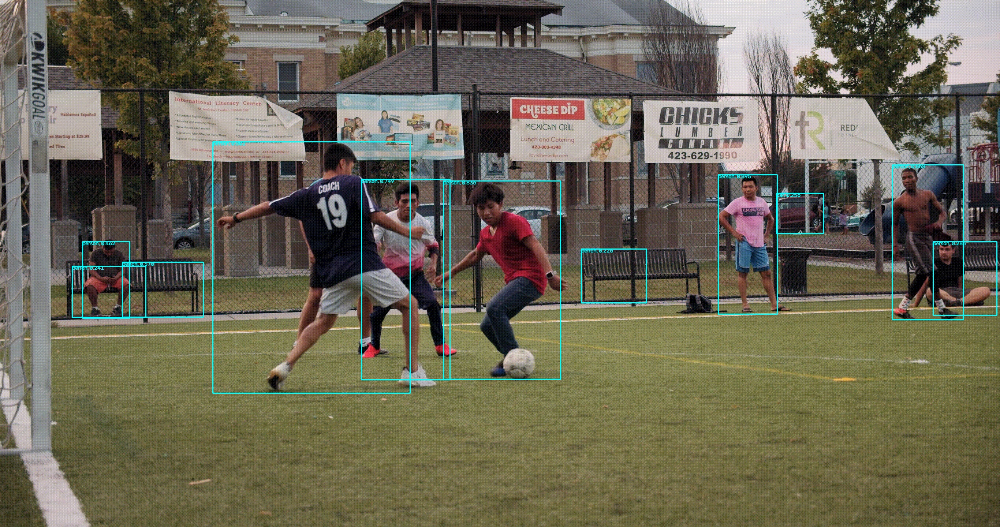

In [36]:
img = Image.open(os.path.join(output_dir, 'frame_00004.jpg'))
img

> 💬 **코멘트**
>
> 중간 프레임 하나를 열어 탐지 결과 확인 (선수·공에 박스가 그려짐).

In [37]:
# 🔄 이미지들을 비디오로 합치기
images = sorted([img for img in os.listdir(output_dir) if img.endswith(".jpg")])
first_frame = cv2.imread(os.path.join(output_dir, images[0]))
height, width, _ = first_frame.shape

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out_video = cv2.VideoWriter(output_video_path, fourcc, 20.0, (width, height))  # 20fps

for image_file in images:
    img = cv2.imread(os.path.join(output_dir, image_file))
    out_video.write(img)

out_video.release()
print(f"✅ 영상 생성 완료: {output_video_path}")

✅ 영상 생성 완료: /content/Yet-Another-EfficientDet-Pytorch/output_soccer.mp4


> 💬 **코멘트**
>
> 저장된 프레임들을 이름순 정렬 → **20fps mp4 영상**으로 합친다.
> - 원본 영상의 fps와 다르면 결과 영상 속도가 빨라지거나 느려질 수 있다. `cap.get(cv2.CAP_PROP_FPS)`로 원본 fps를 읽어 쓰면 더 정확하다.

In [38]:
os.path.exists(output_video_path)

True

> 💬 **코멘트**
>
> `True` → 결과 영상 생성 완료.

---
### 💡 영상 분석 흐름 요약
영상 = 이미지의 연속이므로 **이미지 추론을 프레임마다 반복**하는 구조다.
`VideoCapture`로 프레임 읽기 → 이미지 추론과 같은 전처리/추론/후처리 → 프레임 저장 → `VideoWriter`로 다시 영상 만들기.

### 학습

## Custom dataset 학습 (Car video)
https://www.kaggle.com/datasets/pkdarabi/vehicle-detection-image-dataset

### 1. 데이터셋 준비

- Yet-Another-EfficientDet-Pytorch
    - datasets
        - car_detect
            - Apply_Grayscale
                - Apply_Grayscale
                    - Vehicles_Detection.v9i.coco
                        - test
                            - _annotations.coco.json
                            - XXXX.jpg
                        - train
                        - valid
                

- Yet-Another-EfficientDet-Pytorch
    - projects
        - my_car_detect_proj.yml
    - datasets
        - car_detect
        - my_car_detect_proj
            - annotations
                - instances_train.json
                - instances_valid.json
                - instances_test.json
            - train
                - XXX.jpg
                - XXX.jpg
            - valid
                - XXX.jpg
                - XXX.jpg
            - test
                - XXX.jpg
                - XXX.jpg


### 2. yml 파일 준비

 - projects
     - my_car_detect_proj.yml

![image.png](attachment:image.png)

In [39]:
import os
import json
import cv2
import matplotlib.pyplot as plt

def show_single_coco_image(
    coco_json_path,
    image_dir,
    image_index=0  # 시각화할 이미지 순서 (0부터 시작)
):
    # Load annotation JSON
    with open(coco_json_path, 'r') as f:
        coco = json.load(f)

    # Map image_id to image metadata
    image_info = coco['images'][image_index]
    image_id = image_info['id']
    file_name = image_info['file_name']
    img_path = os.path.join(image_dir, file_name)

    # Load image
    img = cv2.imread(img_path)
    if img is None:
        print(f"이미지를 불러올 수 없습니다: {img_path}")
        return

    # Index annotations for this image
    anns = [ann for ann in coco['annotations'] if ann['image_id'] == image_id]
    cat_id_to_name = {cat['id']: cat['name'] for cat in coco['categories']}

    # Draw bounding boxes
    for ann in anns:
        x, y, w, h = map(int, ann['bbox'])
        category_id = ann['category_id']
        label = cat_id_to_name.get(category_id, str(category_id))

        cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 2)
        cv2.putText(img, label, (x, y - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)

    # Convert BGR to RGB for matplotlib
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Show image
    plt.figure(figsize=(10, 10))
    plt.imshow(img_rgb)
    plt.title(file_name)
    plt.axis('off')
    plt.show()


> 💬 **코멘트**
>
> COCO 어노테이션을 이미지 위에 그려서 **라벨이 제대로 붙어 있는지 확인**하는 함수.
> - COCO 박스 형식은 `[x, y, w, h]`(왼쪽 위 + 너비·높이)라서 `cv2.rectangle`에는 `(x+w, y+h)`로 바꿔 넣는다.
> - OpenCV는 BGR, matplotlib은 RGB라서 표시 전에 색 순서를 변환.

In [40]:
!ls -l

total 268948
-rw-r--r-- 1 root root      3672 Sep 15 05:45 backbone.py
drwxr-xr-x 2 root root      4096 Sep 15 05:45 benchmark
-rw-r--r-- 1 root root      5465 Sep 15 05:45 coco_eval.py
drwxr-xr-x 3 root root      4096 Sep 15 05:45 efficientdet
-rw-r--r-- 1 root root      5013 Sep 15 05:45 efficientdet_test.py
-rw-r--r-- 1 root root      4027 Sep 15 05:45 efficientdet_test_videos.py
drwxr-xr-x 3 root root      4096 Sep 15 05:45 efficientnet
-rw-r--r-- 1 root root      7652 Sep 15 05:45 LICENSE
-rw-r--r-- 1 root root       683 Sep 15 05:48 my_car_detect_proj.yml
drwxr-xr-x 2 root root      4096 Sep 15 05:46 output_soccer_frames
-rw-r--r-- 1 root root   6841667 Sep 15 05:47 output_soccer.mp4
drwxr-xr-x 2 root root      4096 Sep 15 05:45 projects
drwxr-xr-x 2 root root      4096 Sep 15 05:45 __pycache__
-rw-r--r-- 1 root root     16644 Sep 15 05:45 readme.md
drwxr-xr-x 2 root root      4096 Sep 15 05:45 res
-rw-r--r-- 1 root root 268435456 Sep 15 05:48 soccer.mp4
drwxr-xr-x 2 root root   

> 💬 **코멘트**
>
> `datasets/archive.zip`(Kaggle 데이터)이 업로드됐는지 확인.

In [41]:
!pwd

/content/Yet-Another-EfficientDet-Pytorch


> 💬 **코멘트**
>
> 현재 위치 확인.

In [44]:
!unzip ./datasets/archive.zip -d ./datasets/car_detect

Archive:  ./datasets/archive.zip
  inflating: ./datasets/car_detect/Apply_Grayscale/Apply_Grayscale/Vehicles_Detection.v9i.coco/test/_annotations.coco.json  
  inflating: ./datasets/car_detect/Apply_Grayscale/Apply_Grayscale/Vehicles_Detection.v9i.coco/test/frame_0990_jpg.rf.a3223422e734a57442ee34a58d24d4b4.jpg  
  inflating: ./datasets/car_detect/Apply_Grayscale/Apply_Grayscale/Vehicles_Detection.v9i.coco/test/frame_1004_jpg.rf.a6f441255e54620ea11fb3cf34fc0a97.jpg  
  inflating: ./datasets/car_detect/Apply_Grayscale/Apply_Grayscale/Vehicles_Detection.v9i.coco/test/frame_1018_jpg.rf.185b0b25bb53e1d0eb860dda162bb2ae.jpg  
  inflating: ./datasets/car_detect/Apply_Grayscale/Apply_Grayscale/Vehicles_Detection.v9i.coco/test/frame_1806_jpg.rf.4583992e61114207bd9379b7e0652549.jpg  
  inflating: ./datasets/car_detect/Apply_Grayscale/Apply_Grayscale/Vehicles_Detection.v9i.coco/test/frame_3837_jpg.rf.7cdff66e6350318c835a7cf1b35525f0.jpg  
  inflating: ./datasets/car_detect/Apply_Grayscale/Apply_

> 💬 **코멘트**
>
> 데이터셋 압축 해제. 안에 두 가지 버전이 들어 있다.
> - `Apply_Grayscale / ...v9i.coco` : 흑백 처리된 버전
> - `No_Apply_Grayscale / ...v8i.coco` : 원본 컬러 버전

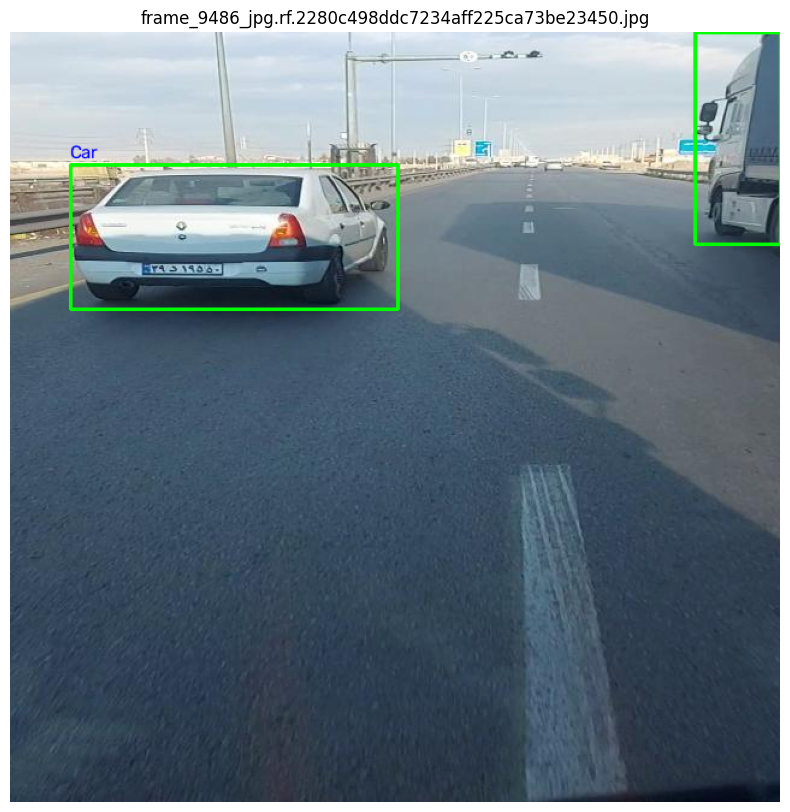

In [45]:
show_single_coco_image(
    coco_json_path='./datasets/car_detect/No_Apply_Grayscale/No_Apply_Grayscale/Vehicles_Detection.v8i.coco/test/_annotations.coco.json',
    image_dir='./datasets/car_detect/No_Apply_Grayscale/No_Apply_Grayscale/Vehicles_Detection.v8i.coco/test',
    image_index=0  # 첫 번째 이미지 시각화
)


> 💬 **코멘트**
>
> 테스트 이미지 1장에 정답 박스를 그려 확인. 도로 위 차량들이 **아주 작게** 찍혀 있다는 점이 눈에 띈다.
> ※ 여기서는 `No_Apply_Grayscale(v8i)`를 보고 있다는 점 기억해 두기.

### mean, std, anchor 계산

In [46]:
import os
import cv2
import numpy as np
from glob import glob
from tqdm import tqdm

def compute_mean_std(image_dir, max_images=None):
    image_paths = sorted(glob(os.path.join(image_dir, '*.jpg')))
    if max_images:
        image_paths = image_paths[:max_images]

    means = []
    stds = []

    for path in tqdm(image_paths, desc="Computing mean/std"):
        img = cv2.imread(path)  # BGR
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = img / 255.0
        means.append(np.mean(img, axis=(0, 1)))
        stds.append(np.std(img, axis=(0, 1)))

    mean = np.mean(means, axis=0)
    std = np.mean(stds, axis=0)

    print(f"✅ RGB mean: {mean.tolist()}")
    print(f"✅ RGB std : {std.tolist()}")
    return mean.tolist(), std.tolist()

> 💬 **코멘트**
>
> 커스텀 데이터의 **RGB 평균·표준편차**를 계산하는 함수 → yml의 `mean`, `std`에 넣을 값.
> - 사전학습은 COCO의 mean/std로 정규화되어 있어서, 데이터 분포가 많이 다르면 직접 계산한 값을 쓰는 게 낫다.
> - 이미지별 std의 평균을 쓰므로 전체 픽셀 std와는 약간 다른 근사값이다.

In [47]:
compute_mean_std('./datasets/car_detect/No_Apply_Grayscale/No_Apply_Grayscale/Vehicles_Detection.v8i.coco/train', max_images=500)  # 샘플 500장 기준

Computing mean/std: 100%|██████████| 102/102 [00:02<00:00, 35.87it/s]

✅ RGB mean: [0.4639068720376132, 0.4723598790503507, 0.4700067273366889]
✅ RGB std : [0.16533415666407805, 0.16423948194385204, 0.16310458962308103]


([0.4639068720376132, 0.4723598790503507, 0.4700067273366889],
 [0.16533415666407805, 0.16423948194385204, 0.16310458962308103])

> 💬 **코멘트**
>
> train 이미지 **102장** 기준 결과: mean ≈ 0.46~0.47, std ≈ 0.16 (R·G·B가 거의 같음 → 회색 톤이 많은 도로 영상).
> ⚠️ **주의**: 이 값은 `No_Apply_Grayscale(v8i)`에서 계산했는데, 아래 셀 63~64에서 실제 학습에 복사하는 데이터는 `Apply_Grayscale(v9i)`다. **분석한 데이터와 학습한 데이터가 다르다.**

In [48]:
import json
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

def analyze_bbox_ratios_and_scales(coco_json_path, show_plots=True):

    with open(coco_json_path, 'r') as f:
        coco = json.load(f)

    # 바운딩 박스 정보 추출
    widths, heights, areas = [], [], []
    category_stats = defaultdict(list)  # 카테고리별 통계

    # 카테고리 이름 매핑
    cat_id_to_name = {cat['id']: cat['name'] for cat in coco['categories']}

    for ann in coco['annotations']:
        x, y, w, h = ann['bbox']
        if w > 0 and h > 0:  # 유효한 바운딩 박스만
            widths.append(w)
            heights.append(h)
            areas.append(w * h)

            # 카테고리별 분석을 위해
            cat_name = cat_id_to_name.get(ann['category_id'], 'unknown')
            category_stats[cat_name].append((w, h))

    widths = np.array(widths)
    heights = np.array(heights)
    areas = np.array(areas)

    # 1. Aspect Ratios 계산
    ratios = widths / heights

    # 2. Scales 계산 (면적의 제곱근)
    scales = np.sqrt(areas)

    # 3. 시각화
    if show_plots:
        plt.figure(figsize=(15, 5))

        # Aspect Ratios 히스토그램
        plt.subplot(1, 3, 1)
        plt.hist(ratios, bins=50, alpha=0.7, edgecolor='black')
        plt.axvline(np.median(ratios), color='red', linestyle='--',
                   label=f'Median: {np.median(ratios):.2f}')
        plt.xlabel('Aspect Ratio (W/H)')
        plt.ylabel('Frequency')
        plt.title('Distribution of Aspect Ratios')
        plt.legend()
        plt.grid(True, alpha=0.3)

        # Scales 히스토그램
        plt.subplot(1, 3, 2)
        plt.hist(scales, bins=50, alpha=0.7, edgecolor='black')
        plt.axvline(np.median(scales), color='red', linestyle='--',
                   label=f'Median: {np.median(scales):.1f}')
        plt.xlabel('Scale (sqrt of area)')
        plt.ylabel('Frequency')
        plt.title('Distribution of Scales')
        plt.legend()
        plt.grid(True, alpha=0.3)

        # Log scale로 스케일 분포 확인
        plt.subplot(1, 3, 3)
        plt.hist(np.log(scales), bins=50, alpha=0.7, edgecolor='black')
        plt.xlabel('Log Scale')
        plt.ylabel('Frequency')
        plt.title('Distribution of Log Scales')
        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    # 4. 통계 정보 출력
    print("📊 데이터셋 통계")
    print(f"총 annotation 수: {len(widths)}")
    print(f"평균 크기: {np.mean(scales):.1f}")
    print(f"중앙값 크기: {np.median(scales):.1f}")
    print(f"평균 비율: {np.mean(ratios):.2f}")
    print(f"중앙값 비율: {np.median(ratios):.2f}")
    print()

    # 5. Anchor Ratios 추천 (20%, 50%, 80% percentile)
    ratio_percentiles = np.percentile(ratios, [20, 50, 80])
    print("🎯 추천 Anchor Ratios")
    print("Percentile 기반 (20%, 50%, 80%):")

    # 단일 값 형태 (EfficientDet/YOLO 스타일)
    ratios_simple = [round(r, 2) for r in ratio_percentiles]
    print(f"  Simple format: {ratios_simple}")

    # Tuple 형태 (일부 구현체용)
    ratios_tuple = [(1.0, round(1/r, 2)) if r > 1 else (round(r, 2), 1.0)
                   for r in ratio_percentiles]
    print(f"  Tuple format: {ratios_tuple}")
    print()

    # 6. Anchor Scales 추천
    scale_percentiles = np.percentile(scales, [20, 50, 80])
    base_scale = scale_percentiles[1]  # 중앙값을 기준으로
    scales_normalized = [round(s / base_scale, 2) for s in scale_percentiles]

    print("📏 추천 Anchor Scales")
    print(f"절대값: {[round(s, 1) for s in scale_percentiles]}")
    print(f"정규화 (중앙값 기준): {scales_normalized}")
    print(f"기준 크기: {base_scale:.1f}")
    print()

    # 7. 실제 사용 예시
    print("💡 실제 설정 예시")
    print("# EfficientDet/RetinaNet 스타일")
    print(f"anchor_ratios = {ratios_simple}")
    print(f"anchor_scales = {scales_normalized}")
    print("")
    print("# 또는 전통적인 설정")
    print("anchor_ratios = [0.5, 1.0, 2.0]")
    print("anchor_scales = [1.0, 1.26, 1.587]  # 2^(0/3), 2^(1/3), 2^(2/3)")
    print()

    # 8. 카테고리별 분석 (상위 5개)
    print("📋 주요 카테고리별 비율 분석")
    cat_ratios = {}
    for cat_name, boxes in category_stats.items():
        if len(boxes) >= 10:  # 충분한 샘플이 있는 카테고리만
            boxes = np.array(boxes)
            cat_ratios[cat_name] = np.median(boxes[:, 0] / boxes[:, 1])

    # 빈도 기준 정렬
    sorted_cats = sorted(cat_ratios.items(),
                        key=lambda x: len(category_stats[x[0]]),
                        reverse=True)[:5]

    for cat_name, median_ratio in sorted_cats:
        count = len(category_stats[cat_name])
        print(f"  {cat_name}: {median_ratio:.2f} (samples: {count})")

    return {
        'ratios_simple': ratios_simple,
        'ratios_tuple': ratios_tuple,
        'scales_normalized': scales_normalized,
        'scales_absolute': [round(s, 1) for s in scale_percentiles],
        'base_scale': base_scale,
        'stats': {
            'total_annotations': len(widths),
            'mean_ratio': np.mean(ratios),
            'median_ratio': np.median(ratios),
            'mean_scale': np.mean(scales),
            'median_scale': np.median(scales)
        }
    }


> 💬 **코멘트**
>
> 어노테이션 박스의 **가로세로 비율과 크기 분포**를 분석해서 데이터에 맞는 앵커를 추천하는 함수.
> - ratio = W/H, scale = √(넓이)
> - 20 / 50 / 80 퍼센타일을 앵커 후보로 사용, scale은 중앙값으로 나눠 정규화
> - 앵커가 실제 물체 모양과 비슷해야 학습 초기부터 매칭이 잘 되고 정확도가 오른다.

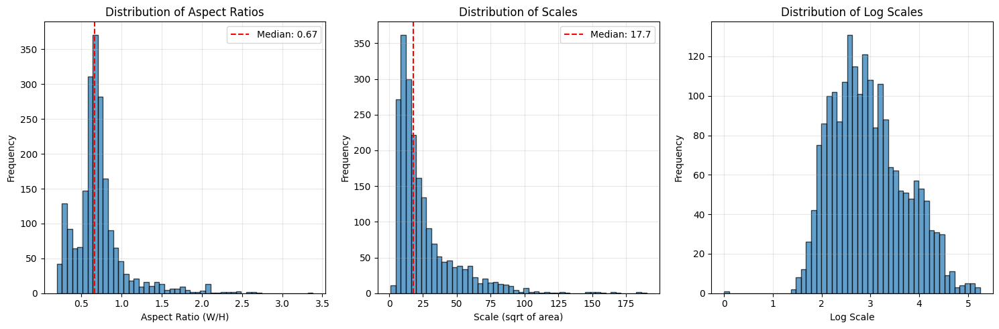

📊 데이터셋 통계
총 annotation 수: 2069
평균 크기: 25.8
중앙값 크기: 17.7
평균 비율: 0.71
중앙값 비율: 0.67

🎯 추천 Anchor Ratios
Percentile 기반 (20%, 50%, 80%):
  Simple format: [np.float64(0.52), np.float64(0.67), np.float64(0.82)]
  Tuple format: [(np.float64(0.52), 1.0), (np.float64(0.67), 1.0), (np.float64(0.82), 1.0)]

📏 추천 Anchor Scales
절대값: [np.float64(9.6), np.float64(17.7), np.float64(37.6)]
정규화 (중앙값 기준): [np.float64(0.54), np.float64(1.0), np.float64(2.13)]
기준 크기: 17.7

💡 실제 설정 예시
# EfficientDet/RetinaNet 스타일
anchor_ratios = [np.float64(0.52), np.float64(0.67), np.float64(0.82)]
anchor_scales = [np.float64(0.54), np.float64(1.0), np.float64(2.13)]

# 또는 전통적인 설정
anchor_ratios = [0.5, 1.0, 2.0]
anchor_scales = [1.0, 1.26, 1.587]  # 2^(0/3), 2^(1/3), 2^(2/3)

📋 주요 카테고리별 비율 분석
  Car: 0.71 (samples: 1527)
  Motorcycle: 0.31 (samples: 281)
  Pickup: 0.56 (samples: 190)
  Truck: 1.45 (samples: 47)
  Bus: 0.36 (samples: 24)


{'ratios_simple': [np.float64(0.52), np.float64(0.67), np.float64(0.82)],
 'ratios_tuple': [(np.float64(0.52), 1.0),
  (np.float64(0.67), 1.0),
  (np.float64(0.82), 1.0)],
 'scales_normalized': [np.float64(0.54), np.float64(1.0), np.float64(2.13)],
 'scales_absolute': [np.float64(9.6), np.float64(17.7), np.float64(37.6)],
 'base_scale': np.float64(17.663521732655695),
 'stats': {'total_annotations': 2069,
  'mean_ratio': np.float64(0.7142181132304681),
  'median_ratio': np.float64(0.6666666666666666),
  'mean_scale': np.float64(25.800453307673692),
  'median_scale': np.float64(17.663521732655695)}}

In [49]:
analyze_bbox_ratios_and_scales('./datasets/car_detect/No_Apply_Grayscale/No_Apply_Grayscale/Vehicles_Detection.v8i.coco/train/_annotations.coco.json')

> 💬 **코멘트**
>
> 분석 결과 해석:
> - **중앙값 크기 17.7px** → 512 입력 기준으로도 매우 작은 물체 (small object 문제)
> - 비율 중앙값 0.67 → 세로가 더 긴 박스가 많음
> - 추천값: `ratios [(0.52,1.0), (0.67,1.0), (0.82,1.0)]`, `scales [0.54, 1.0, 2.13]`
> - 클래스 불균형: **Car 1527개** vs Bus 24개, Truck 47개 → 적은 클래스는 학습이 잘 안 될 가능성이 크다.
> ⚠️ 이 분석도 `No_Apply_Grayscale(v8i)` 기준.

In [50]:
import json

def extract_obj_list(coco_json_path):
    with open(coco_json_path, 'r') as f:
        coco = json.load(f)

    obj_list = [cat['name'] for cat in sorted(coco['categories'], key=lambda x: x['id'])]
    print("obj_list:", obj_list)
    return obj_list


> 💬 **코멘트**
>
> 어노테이션 json에서 클래스 이름을 **id 순서대로** 뽑아 yml의 `obj_list`로 쓰는 함수.

In [51]:
extract_obj_list('./datasets/car_detect/No_Apply_Grayscale/No_Apply_Grayscale/Vehicles_Detection.v8i.coco/train/_annotations.coco.json')

obj_list: ['cars', 'Bus', 'Car', 'Motorcycle', 'Pickup', 'Truck']


['cars', 'Bus', 'Car', 'Motorcycle', 'Pickup', 'Truck']

> 💬 **코멘트**
>
> 결과: `['cars', 'Bus', 'Car', 'Motorcycle', 'Pickup', 'Truck']`
> - 맨 앞 `cars`는 Roboflow가 자동으로 넣는 **상위 카테고리(id 0)** 로, 실제 박스는 없다.
> ⚠️ 이 저장소는 학습할 때 `category_id - 1`을 라벨로 쓰는데(yml 주석의 "category_id is one_indexed"), 그러면 Bus(id 1)가 라벨 0이 된다. 그런데 `obj_list[0]`은 `'cars'`라서 **추론 결과의 클래스 이름이 한 칸씩 밀려 표시될 가능성**이 있다. → `obj_list`에서 `'cars'`를 빼는 쪽이 저장소 규칙에 맞다.

- Yet-Another-EfficientDet-Pytorch
    - projects
        - my_car_detect_proj.yml
    - datasets
        - car_detect
        - my_car_detect
            - annotations
                - instances_train.json
                - instances_valid.json
                - instances_test.json
            - train
                - XXX.jpg
                - XXX.jpg
            - valid
                - XXX.jpg
                - XXX.jpg
            - test
                - XXX.jpg
                - XXX.jpg


![image.png](attachment:image.png)

![image.png](attachment:image.png)

![image.png](attachment:image.png)

In [52]:
import os
import shutil
import json
from pathlib import Path

# 1) 설정: 원본/대상 경로 및 split 정의
SRC_ROOT = Path("datasets/car_detect/Apply_Grayscale/Apply_Grayscale/Vehicles_Detection.v9i.coco")
DST_ROOT = Path("datasets/my_car_detect_proj")
ANNOT_DIR = DST_ROOT / "annotations"
SPLITS = ["train", "valid", "test"]

# 2) 대상 디렉토리 생성
for p in [DST_ROOT, ANNOT_DIR] + [DST_ROOT / s for s in SPLITS]:
    p.mkdir(parents=True, exist_ok=True)

# 3) split별 이미지 복사 및 annotation 변환·저장
for split in SPLITS:
    src_split = SRC_ROOT / split
    dst_split = DST_ROOT / split
    dst_split.mkdir(exist_ok=True)

    # 3-1) 이미지 파일(.jpg/.png) 복사
    for ext in ("*.jpg", "*.png"):
        for img_path in src_split.glob(ext):
            shutil.copy(img_path, dst_split / img_path.name)

    # 3-2) annotation JSON 변환
    #    - 원본 JSON 불러오기
    #    - COCO to EfficientDet-PyTorch 형식 변환
    #    - instances_{split}.json으로 저장
    for json_path in src_split.glob("*.json"):
        with open(json_path, "r", encoding="utf-8") as f:
            before = json.load(f)

        # 새 구조 준비
        tobe = {
            "images": [],
            "type": "instances",
            "annotations": [],
            "categories": []
        }

        # images 필드
        for img in before.get("images", []):
            tobe["images"].append({
                "file_name": img["file_name"],
                "height": img["height"],
                "width": img["width"],
                "id": img["id"]
            })

        # annotations 필드
        for ann in before.get("annotations", []):
            tobe["annotations"].append({
                "id": ann["id"],
                "image_id": ann["image_id"],
                "category_id": ann["category_id"],
                "bbox": ann["bbox"],
                "area": ann["area"],
                "iscrowd": ann.get("iscrowd", 0),
                "ignore": 0,
                "segmentation": ann.get("segmentation", [])
            })

        # categories 필드
        for cat in before.get("categories", []):
            tobe["categories"].append({
                "supercategory": cat.get("supercategory", ""),
                "id": cat["id"],
                "name": cat["name"]
            })

        # 저장
        dst_json = ANNOT_DIR / f"instances_{split}.json"
        with open(dst_json, "w", encoding="utf-8") as f:
            json.dump(tobe, f, ensure_ascii=False, indent=2)

        print(f"[{split}] {json_path.name} → {dst_json.name}")

print("✅ 전체 폴더 구조 및 annotation 변환 완료!")


[train] _annotations.coco.json → instances_train.json
[valid] _annotations.coco.json → instances_valid.json
[test] _annotations.coco.json → instances_test.json
✅ 전체 폴더 구조 및 annotation 변환 완료!


> 💬 **코멘트**
>
> 원본 데이터를 저장소가 요구하는 폴더 구조(`datasets/<프로젝트명>/train, valid, test, annotations/instances_*.json`)로 옮기는 코드.
> - 이미지는 split별로 복사
> - json은 EfficientDet-PyTorch 형식에 맞게 필드를 다시 정리해서(`ignore` 필드 추가 등) `instances_{split}.json`으로 저장
> ⚠️ 원본 경로가 `Apply_Grayscale(v9i)` → mean/std·앵커를 분석한 데이터(v8i)와 다르다.

In [53]:
import os
import shutil
from pathlib import Path

# 원본 루트 (변경 필요 시 수정)
SRC_ROOT = Path("datasets/car_detect/Apply_Grayscale/Apply_Grayscale/Vehicles_Detection.v9i.coco")

# 대상 루트
DST_ROOT = Path("datasets/my_car_detect_proj")
ANNOT_DIR = DST_ROOT / "annotations"

# splits 정보
SPLITS = ["train", "valid", "test"]

# annotation 파일 패턴 (원본 디렉토리 안에서 *.json 찾기)
ANNOT_PATTERN = "_annotations.coco.json"  # test에만 있다면 'test'만 복사됩니다.

# 1) 대상 디렉토리 생성
for d in [DST_ROOT, ANNOT_DIR] + [DST_ROOT / s for s in SPLITS]:
    d.mkdir(parents=True, exist_ok=True)

# 2) 이미지 파일 복사 및 annotation 파일 복사
for split in SPLITS:
    src_split = SRC_ROOT / split
    dst_split = DST_ROOT / split

    # 이미지(.jpg/.png) 복사
    for ext in ("*.jpg", "*.png"):
        for img_path in src_split.glob(ext):
            shutil.copy(img_path, dst_split / img_path.name)

    # annotation JSON 복사 (split별로 이름 바꿔 복사)
    # 만약 train/valid 폴더에도 JSON이 있다면 동일 로직으로 처리됩니다.
    for json_path in src_split.glob("*.json"):
        dst_json = ANNOT_DIR / f"instances_{split}.json"
        shutil.copy(json_path, dst_json)
        print(f"Copied annotation for {split}: {json_path.name} → {dst_json.name}")

print("✅ 폴더 구조 변환 완료!")

Copied annotation for train: _annotations.coco.json → instances_train.json
Copied annotation for valid: _annotations.coco.json → instances_valid.json
Copied annotation for test: _annotations.coco.json → instances_test.json
✅ 폴더 구조 변환 완료!


> 💬 **코멘트**
>
> 폴더 구조 변환을 단순 복사 방식으로 한 번 더 실행한 셀.
> ⚠️ 같은 위치에 `instances_{split}.json`을 **원본 그대로 덮어써서** 바로 위 셀 63에서 변환한 json이 사라진다. 결국 학습에는 Roboflow 원본 json이 사용됐다. (원본도 COCO 형식이라 로딩 자체는 문제없이 됐음)

```python

project_name: car_detect_proj  # also the folder name of the dataset that under data_path folder
train_set: train
val_set: valid
num_gpus: 0

# mean and std in RGB order, actually this part should remain unchanged as long as your dataset is similar to coco.
mean: [0.4639068720376132, 0.4723598790503507, 0.4700067273366889]
std: [0.16533415666407805, 0.16423948194385204, 0.16310458962308103]

# this is coco anchors, change it if necessary
anchors_scales: '[0.54, 1.0, 2.13]'
anchors_ratios: '[(0.52, 1.0), (0.67, 1.0), (0.82, 1.0)]'

# must match your dataset's category_id.
# category_id is one_indexed,
# for example, index of 'car' here is 2, while category_id of is 3
obj_list: ['cars', 'Bus', 'Car', 'Motorcycle', 'Pickup', 'Truck']

```

![image-2.png](attachment:image-2.png)

## 학습

- scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, verbose=True)
- 에러 발생 시 => 아래와 같이 수정
- scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3)

In [54]:
!pip install tensorboardX

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 3.0 MB/s eta 0:00:00


> 💬 **코멘트**
>
> 학습 로그 기록용 `tensorboardX` 설치 (`train.py`에서 import함).

In [55]:
!pwd

/content/Yet-Another-EfficientDet-Pytorch


> 💬 **코멘트**
>
> `train.py`가 있는 저장소 루트에서 실행해야 하므로 위치 확인.

In [60]:
! python train.py -c 0 -p my_car_detect_proj --head_only True --lr 1e-3 --batch_size 16 --load_weights weights/efficientdet-d0.pth  --num_epochs 10 --save_interval 100


loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
[Warning] Ignoring Error(s) in loading state_dict for EfficientDetBackbone:
	size mismatch for classifier.header.pointwise_conv.conv.weight: copying a param with shape torch.Size([810, 64, 1, 1]) from checkpoint, the shape in current model is torch.Size([54, 64, 1, 1]).
	size mismatch for classifier.header.pointwise_conv.conv.bias: copying a param with

> 💬 **코멘트**
>
> **1단계 학습 — head만 학습** (`--head_only True`)
> - backbone(EfficientNet)과 BiFPN은 고정, **분류·박스 head만** 학습 → 적은 데이터로 빠르게 적응시키는 전이학습 방식
> - 실행 로그의 `size mismatch` 경고는 정상: COCO head는 90클래스×9앵커=810채널, 우리 모델은 6클래스×9앵커=**54채널**이라 그 층만 새로 초기화된다.
> - 10 epoch, epoch당 8 iteration (batch 16 → train 약 128장)
>
> **loss 추이 (Val Total loss)**: 5805 → 2687 → 1215 → 528 → 275 → 175 → 132 → **110**
> 꾸준히 줄긴 했지만, 보통 focal loss는 1 안팎에서 시작하는 걸 생각하면 **classification loss 값 자체가 비정상적으로 크다.** 앵커·라벨 설정이 데이터와 맞지 않는다는 신호로 볼 수 있다.
> - iteration당 약 9초로 느린 편 → yml의 `num_gpus: 0` 설정이면 이 저장소의 `train.py`는 **GPU를 끄고 CPU로 학습**한다. 속도를 보면 실제로 CPU로 돌았을 가능성이 크다.

In [62]:
! python train.py -c 0 -p my_car_detect_proj --head_only False --lr 1e-3 --batch_size 16 --load_weights './logs/my_car_detect_proj/efficientdet-d0_9_80.pth'  --num_epochs 30 --save_interval 100

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
[Info] loaded weights: efficientdet-d0_9_80.pth, resuming checkpoint from step: 80
  0% 0/8 [00:00<?, ?it/s]/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoad

> 💬 **코멘트**
>
> **2단계 학습 — 전체 fine-tuning** (`--head_only False`)
> - 1단계 마지막 가중치(`d0_9_80.pth`)에서 이어서 backbone까지 전부 학습하려는 단계
> - iteration당 약 32초로 너무 느려 **첫 step에서 중단(^C)** → 실제로는 1단계 결과만 남았다.

In [63]:
%cd logs/my_car_detect_proj
weight_file = !ls -Art | grep efficientdet
weight_file

/content/Yet-Another-EfficientDet-Pytorch/logs/my_car_detect_proj


['efficientdet-d0_0_8.pth',
 'efficientdet-d0_1_16.pth',
 'efficientdet-d0_2_24.pth',
 'efficientdet-d0_3_32.pth',
 'efficientdet-d0_4_40.pth',
 'efficientdet-d0_5_48.pth',
 'efficientdet-d0_6_56.pth',
 'efficientdet-d0_7_64.pth',
 'efficientdet-d0_8_72.pth',
 'efficientdet-d0_9_80.pth']

> 💬 **코멘트**
>
> 저장된 체크포인트 목록. 파일명 `efficientdet-d0_{epoch}_{step}.pth`.
> `ls -Art`는 수정 시간 오래된 순 → `weight_file[-1]`이 **가장 최근 가중치**(`d0_9_80.pth`).

In [64]:
%cd ..
%cd ..

/content/Yet-Another-EfficientDet-Pytorch/logs
/content/Yet-Another-EfficientDet-Pytorch


> 💬 **코멘트**
>
> 다시 저장소 루트로 복귀.

In [65]:
! python coco_eval.py -c 0 -p my_car_detect_proj -w "logs/my_car_detect_proj/{weight_file[-1]}"

running coco-style evaluation on project my_car_detect_proj, weights logs/my_car_detect_proj/efficientdet-d0_9_80.pth...
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
100% 28/28 [00:12<00:00,  2.32it/s]
Loading and preparing results...
DONE (t=4.26s)
creating index...
index created!
BBox
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=2.51s).
Accumulating evaluation results...
DONE (t=0.11s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.002
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.068
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDe

> 💬 **코멘트**
>
> **COCO 방식 평가** (valid 데이터 기준)
> - AP@[0.5:0.95] = **0.000**, AP50 = **0.000**
> - small 0.000 / medium 0.002 / large 0.068
> → 사실상 탐지가 되지 않는 수준. 작은 물체(small)가 대부분인 데이터라 전체 AP가 0에 가깝다.
> 원인 정리는 노트북 마지막 **"결과 분석 및 개선 방안"** 참고.

In [66]:
os.path.exists('./datasets/car_detect/No_Apply_Grayscale/No_Apply_Grayscale/Vehicles_Detection.v8i.coco/test/frame_0990_jpg.rf.a3223422e734a57442ee34a58d24d4b4.jpg')

True

> 💬 **코멘트**
>
> 추론에 쓸 테스트 이미지가 있는지 확인 (`True`).
> ⚠️ 학습은 흑백(v9i) 데이터로 했는데 테스트는 컬러(v8i) 이미지로 하고 있다.

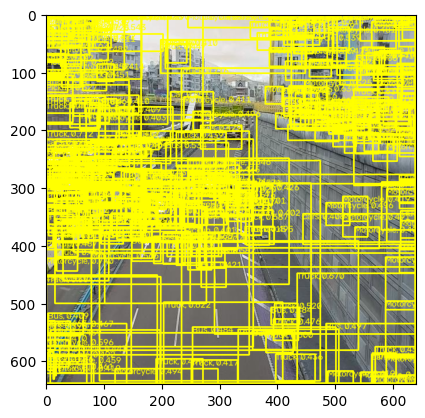

In [67]:
import torch
from torch.backends import cudnn

from backbone import EfficientDetBackbone
import cv2
import matplotlib.pyplot as plt
import numpy as np

from efficientdet.utils import BBoxTransform, ClipBoxes
from utils.utils import preprocess, invert_affine, postprocess

compound_coef = 0
force_input_size = None  # set None to use default size
img_path = './datasets/car_detect/No_Apply_Grayscale/No_Apply_Grayscale/Vehicles_Detection.v8i.coco/test/frame_0990_jpg.rf.a3223422e734a57442ee34a58d24d4b4.jpg'

threshold = 0.4
iou_threshold = 0.2

use_cuda = True
use_float16 = False

obj_list = ['cars', 'Bus', 'Car', 'Motorcycle', 'Pickup', 'Truck']

# tf bilinear interpolation is different from any other's, just make do
input_sizes = [512, 640, 768, 896, 1024, 1280, 1280, 1536]
input_size = input_sizes[compound_coef] if force_input_size is None else force_input_size
ori_imgs, framed_imgs, framed_metas = preprocess(img_path, max_size=input_size)

if use_cuda:
    x = torch.stack([torch.from_numpy(fi).cuda() for fi in framed_imgs], 0)
else:
    x = torch.stack([torch.from_numpy(fi) for fi in framed_imgs], 0)

x = x.to(torch.float32 if not use_float16 else torch.float16).permute(0, 3, 1, 2)

model = EfficientDetBackbone(compound_coef=compound_coef, num_classes=len(obj_list),

                             # replace this part with your project's anchor config
                             ratios=[(1.0, 1.0), (1.3, 0.8), (1.9, 0.5)],
                             scales=[2 ** 0, 2 ** (1.0 / 3.0), 2 ** (2.0 / 3.0)])

model.load_state_dict(torch.load('logs/my_car_detect_proj/'+weight_file[-1]))
model.requires_grad_(False)
model.eval()

if use_cuda:
    model = model.cuda()
if use_float16:
    model = model.half()

with torch.no_grad():
    features, regression, classification, anchors = model(x)

    regressBoxes = BBoxTransform()
    clipBoxes = ClipBoxes()

    out = postprocess(x,
                      anchors, regression, classification,
                      regressBoxes, clipBoxes,
                      threshold, iou_threshold)

out = invert_affine(framed_metas, out)

for i in range(len(ori_imgs)):
    if len(out[i]['rois']) == 0:
        continue
    ori_imgs[i] = ori_imgs[i].copy()
    for j in range(len(out[i]['rois'])):
        (x1, y1, x2, y2) = out[i]['rois'][j].astype(np.int32)
        cv2.rectangle(ori_imgs[i], (x1, y1), (x2, y2), (255, 255, 0), 2)
        obj = obj_list[out[i]['class_ids'][j]]
        score = float(out[i]['scores'][j])

        cv2.putText(ori_imgs[i], '{}, {:.3f}'.format(obj, score),
                    (x1, y1 + 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5,
                    (255, 255, 0), 1)

        plt.imshow(ori_imgs[i])

> 💬 **코멘트**
>
> 학습한 가중치로 **커스텀 추론**.
> - `threshold=0.4`로 올려서 확실한 박스만 보이도록 설정
> - `num_classes=len(obj_list)=6`으로 학습 때와 같은 head 크기
> ⚠️ **가장 큰 문제 지점**: 여기 앵커가 `ratios=[(1.0,1.0),(1.3,0.8),(1.9,0.5)]`로, yml에서 학습에 쓴 `[(0.52,1.0),(0.67,1.0),(0.82,1.0)]` / `scales [0.54, 1.0, 2.13]`과 **완전히 다르다.** head는 학습 때 앵커 기준으로 보정값을 배웠기 때문에 다른 앵커를 넣으면 박스 위치가 전부 어긋난다. → yml과 같은 값을 넣어야 한다.

In [68]:
out

[{'rois': array([[  0.      , 202.79993 , 351.3417  , 589.41077 ],
         [ 39.106026,   0.      ,  81.508675,  33.944244],
         [  0.      , 142.30042 , 102.60778 , 281.5291  ],
         ...,
         [137.92769 , 223.9704  , 173.63173 , 248.90207 ],
         [547.2981  ,  57.726   , 585.2509  ,  90.04139 ],
         [365.18668 ,  32.64614 , 497.09372 ,  62.25453 ]], dtype=float32),
  'class_ids': array([5, 3, 5, 5, 3, 3, 3, 5, 3, 5, 3, 5, 3, 5, 3, 3, 3, 0, 3, 5, 5, 1,
         3, 2, 5, 5, 0, 5, 4, 5, 1, 5, 5, 5, 3, 3, 1, 4, 5, 5, 0, 5, 3, 5,
         3, 1, 3, 5, 3, 0, 5, 5, 0, 5, 5, 5, 5, 5, 3, 1, 0, 3, 0, 3, 0, 3,
         3, 5, 3, 5, 1, 0, 5, 1, 0, 3, 3, 5, 3, 1, 1, 3, 3, 4, 0, 3, 0, 1,
         5, 3, 5, 0, 5, 2, 5, 5, 5, 5, 5, 0, 5, 5, 4, 5, 5, 3, 3, 3, 3, 3,
         3, 3, 5, 3, 3, 3, 2, 5, 5, 1, 0, 1, 4, 3, 3, 2, 5, 3, 3, 4, 5, 1,
         3, 2, 5, 5, 5, 0, 3, 3, 1, 5, 5, 5, 3, 0, 3, 3, 1, 3, 3, 1, 2, 0,
         1, 3, 5, 3, 3, 5, 5, 1, 0, 2, 3, 3, 5, 3, 2, 3, 3, 1, 5, 4, 

> 💬 **코멘트**
>
> 결과: 점수 0.40~0.48 사이의 박스가 **수백 개** 나오고, 클래스도 섞여서 나온다.
> 점수가 고르게 0.4 근처에 몰려 있다는 건 모델이 확신 없이 예측하고 있다는 뜻 → 위의 평가 결과(AP 0)와 같은 결론.

---
## 📊 결과 분석 및 개선 방안

학습 loss는 줄었지만 평가 결과는 **AP = 0.000**. 코드를 따라가며 찾은 원인 후보는 다음과 같다. (코드는 실행했던 그대로 두고 분석만 정리)

| # | 문제 | 위치 | 개선 방안 |
|---|---|---|---|
| 1 | **학습·추론 앵커 불일치** — 학습은 `ratios [(0.52,1.0),(0.67,1.0),(0.82,1.0)]`, 추론은 `[(1.0,1.0),(1.3,0.8),(1.9,0.5)]` | 셀 65 ↔ 셀 78 | 추론 코드에 yml과 같은 ratios/scales 사용 |
| 2 | **분석 데이터 ≠ 학습 데이터** — mean/std·앵커는 컬러(v8i)로 분석, 학습은 흑백(v9i), 테스트는 다시 컬러(v8i) | 셀 54·56 ↔ 셀 63·64 ↔ 셀 77 | 한 가지 버전으로 통일해서 분석·학습·테스트 |
| 3 | **학습량 부족** — head만 10 epoch, 전체 fine-tuning은 첫 step에서 중단 | 셀 71·72 | GPU 사용(`num_gpus: 1`) 후 전체 학습을 충분히 진행 |
| 4 | **obj_list의 `'cars'`** — 저장소는 `category_id - 1`을 라벨로 사용 → 클래스 이름이 한 칸 밀릴 가능성 | 셀 58·65 | `obj_list`에서 `'cars'` 제거 (num_classes 5) |
| 5 | **작은 물체 + 클래스 불균형** — 박스 중앙값 17.7px, Car 1527개 vs Bus 24개 | 셀 56 | 입력 해상도 키우기(D1~D2 또는 `force_input_size`), 데이터 증강 |
| 6 | 변환한 json을 원본 복사로 **덮어씀** | 셀 63 → 64 | 둘 중 하나만 실행 |

> 특히 1번은 head가 학습한 박스 보정값이 **엉뚱한 앵커**에 적용되는 것이라, 이것만 고쳐도 추론 결과가 크게 달라질 것으로 예상된다.
> 또 학습 중 classification loss가 수천 단위로 매우 컸던 것도 앵커·라벨 설정이 데이터와 맞지 않았다는 신호로 볼 수 있다.

---
## ✍️ 느낀 점

**1. 사전학습 모델의 위력**
코드 몇 줄과 15MB짜리 D0 가중치만으로 처음 보는 이미지와 축구 영상에서 사람·공을 바로 잡아내는 것이 인상적이었다. 4만 9천 개의 앵커 후보 중에서 후처리를 거쳐 37개의 박스만 남는 과정을 직접 출력해 보면서, "탐지 모델 = 후보를 많이 깔고 걸러내는 구조"라는 것을 숫자로 이해할 수 있었다.

**2. 데이터 준비가 학습보다 어렵다**
정작 `train.py` 실행은 한 줄이었지만, 그 한 줄을 위해 폴더 구조 맞추기, COCO json 변환, mean/std 계산, 앵커 분석, yml 작성까지 훨씬 많은 단계가 필요했다. 경로 하나, 데이터 버전 하나만 달라져도 결과가 완전히 달라질 수 있다는 걸 체감했다.

**3. 학습 결과의 아쉬움 — 일관성의 중요성**
loss가 5805에서 110까지 내려가서 잘 되고 있다고 생각했는데 평가 결과는 AP 0이었다. 다시 따라가 보니 학습과 추론의 앵커가 달랐고, 분석한 데이터와 학습한 데이터도 달랐다. **"loss가 줄었다 ≠ 모델이 잘 된다"**, 그리고 **학습·추론·평가에서 설정을 똑같이 유지하는 것**이 얼마나 중요한지 배웠다. 다음에는 앵커와 데이터 버전을 통일하고 GPU로 충분히 학습시켜 결과를 비교해 보고 싶다.

**4. 제조 현장 적용 가능성**
강의 주제가 "제조 영상 분석"인 만큼, PCB 사진(`normal.png`)처럼 제조 현장 이미지에 적용하면 부품 누락·불량 위치를 찾는 데 쓸 수 있을 것 같다. 이번 차량 데이터처럼 PCB의 부품·결함도 **작은 물체**라서, 실습에서 배운 앵커 분석과 입력 해상도 조절이 그대로 중요하게 쓰일 것이다. 또 D0처럼 가벼운 모델은 실시간 라인 검사에도 활용할 수 있을 것 같다.